# 闭环反馈频率标定测试

测试 `SinglePointFrequencyCalibration`（闭环调谐）两种内部频率测量方式（由 `FrequencyMeasurement` 提供）：
- **Ramsey FFT**：扫描 $\tau$ 得到 Ramsey 振荡，FFT 提取失谐频率
- **Transient（核函数）**：正交 Ramsey 读出差分 $p_e$，通过核函数灵敏度 $G_\alpha$ 直接得到 $\delta\omega$

理论参考：`_sensing theory.md` §闭环反馈控制 (Vepsäläinen 2022) 和 §瞬态磁场协议与核函数策略

## 0. 环境与全局配置

In [20]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sqc.config import CONFIG
from sqc.devices.transmon import TransmonQubit
from sqc.control.flux_signal import FluxSignal

print(f"AWG dt = {CONFIG.awg.dt} ns")
print(f"t_rabi: {CONFIG.pulse.t_rabi[0]:.1f} → {CONFIG.pulse.t_rabi[-1]:.1f} ns, N={len(CONFIG.pulse.t_rabi)}")
print(f"Transmon defaults: EC={CONFIG.transmon.EC:.2f}, EJ={CONFIG.transmon.EJ:.1f} GHz·2π")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
AWG dt = 0.5 ns
t_rabi: 0.0 → 9.5 ns, N=20
Transmon defaults: EC=0.20, EJ=15.0 GHz·2π


## 1. 创建 Qubit 并执行磁通响应粗标定

闭环反馈需要预先知道目标频率对应的电压区间 $[V_a, V_b]$，这由 `FluxResponseCalibration` 提供。
设定目标频率为 qubit 的裸频率（零磁通处）。

In [21]:
# --- 创建 qubit ---
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi,
    EJ=10.0 * 2 * np.pi,
    T1=100.0e3,
    T2=50.0e3,
    flux=0.0,
    n_levels=2,
)
f_bare = qubit.frequency  # 零磁通处频率
print(f"qubit bare frequency (Φ=0): {f_bare/(2*np.pi):.4f} GHz")

qubit bare frequency (Φ=0): 3.8000 GHz


Running FluxResponseCalibration (ramsey scan)...
f(Φ) table: 15 points, Φ in [-0.030, 0.030] Φ₀
Target: f at Φ=0.025 ≈ 3.806690 GHz
  bare f at Φ=0 = 3.800000 GHz
  detuning ≈ 6.7 MHz (> FFT resolution of ~2 MHz)


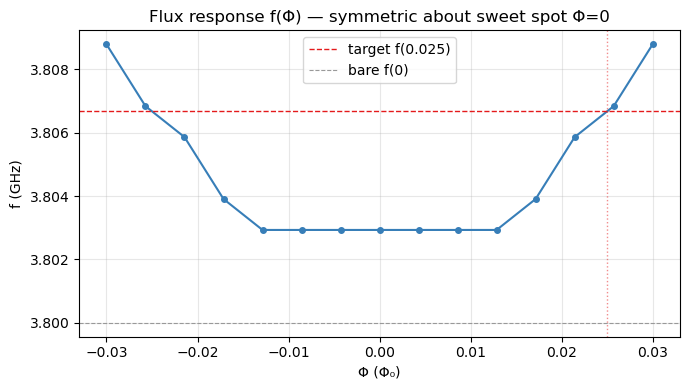

In [22]:
from sqc.calibration.frequency import FluxResponseCalibration
from scipy.interpolate import interp1d

# --- 粗标定：扫描磁通 → 拟合 f(Φ) 曲线 ---
print("Running FluxResponseCalibration (ramsey scan)...")
flux_cal = FluxResponseCalibration(
    qubit=qubit,
    method="ramsey",
    h_list=np.linspace(-0.03, 0.03, 15),  # 稀疏采样加速
    tau=100.0,
)
flux_table = flux_cal.calibrate()

V_a = float(np.min(flux_table.inputs))
V_b = float(np.max(flux_table.inputs))

# 目标：Φ=0.025 处的频率（~6 MHz detuning，FFT 可以清晰分辨）
f_interp = interp1d(flux_table.inputs, flux_table.outputs, kind="cubic")
f_target = float(f_interp(0.025))

print(f"f(Φ) table: {len(flux_table.inputs)} points, Φ in [{V_a:.3f}, {V_b:.3f}] Φ₀")
print(f"Target: f at Φ=0.025 ≈ {f_target/(2*np.pi):.6f} GHz")
print(f"  bare f at Φ=0 = {f_bare/(2*np.pi):.6f} GHz")
print(f"  detuning ≈ {(f_target-f_bare)/(2*np.pi)*1e3:.1f} MHz (> FFT resolution of ~2 MHz)")

# --- 可视化 f(Φ) ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(flux_table.inputs, np.array(flux_table.outputs) / (2*np.pi), "o-", ms=4, color="#377eb8")
ax.axhline(y=f_target/(2*np.pi), color="#e41a1c", ls="--", lw=1, label=f"target f(0.025)")
ax.axvline(x=0.025, color="#e41a1c", ls=":", lw=1, alpha=0.5)
ax.axhline(y=f_bare/(2*np.pi), color="#999999", ls="--", lw=0.8, label="bare f(0)")
ax.set(xlabel="Φ (Φ₀)", ylabel="f (GHz)", title="Flux response f(Φ) — symmetric about sweet spot Φ=0")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 2. 闭环反馈 — 方法 A：Ramsey FFT 频率测量

每次迭代运行 Ramsey 序列（$\pi/2 - \tau - \pi/2$），扫描 $\tau$，对 $p_e(\tau)$ 做 FFT 提取振荡频率。

Secant 方法更新磁通偏置 $V_n$，迭代直至 $|f_Q(V_n) - f_{target}| < \epsilon_f$。

In [ ]:
from sqc.calibration.frequency import SinglePointFrequencyCalibration

# --- 闭环标定：Ramsey 测量 + 二分法 ---
# 二分法每步将区间宽度减半 → 指数收敛趋势，10+ 次迭代
tau_long = CONFIG.pulse.make_time(0, 500)

cal_ramsey = SinglePointFrequencyCalibration(
    qubit=qubit,
    measure_method="ramsey",
    step_method="bisection",          # 二分法 → 清晰的指数收敛趋势
    tau_list=tau_long,
    f_target=f_target,
    epsilon_f=1e-4 * 2 * np.pi,      # 0.1 MHz tolerance
    V_a=V_a,
    V_b=V_b,
    max_iter=20,
)

print(f"Step method: {cal_ramsey.step_method}")
print(f"Initial bracket: [{V_a:.4f}, {V_b:.4f}] Φ₀, width = {V_b-V_a:.4f} Φ₀")
print(f"Target |Φ| ≈ 0.025, f ≈ {f_target/(2*np.pi):.6f} GHz")
print(f"Expected ~log₂(width/tol) ≈ {np.ceil(np.log2((V_b-V_a)/0.0001)):.0f} iterations")
print("\nStarting closed-loop calibration (ramsey, bisection)...")
result_ramsey = cal_ramsey.calibrate()

fp = result_ramsey.fit_params
print(f"\n--- Results ---")
print(f"Converged: {fp['converged']}")
print(f"Iterations: {fp['n_iter']}")
print(f"Optimal V: {fp['V_opt']:.6f} Φ₀ (target: ~0.025)")
print(f"Final f: {result_ramsey.outputs[0]/(2*np.pi):.6f} GHz")
print(f"Residual: {fp['residual']/(2*np.pi)*1e3:.3f} MHz")

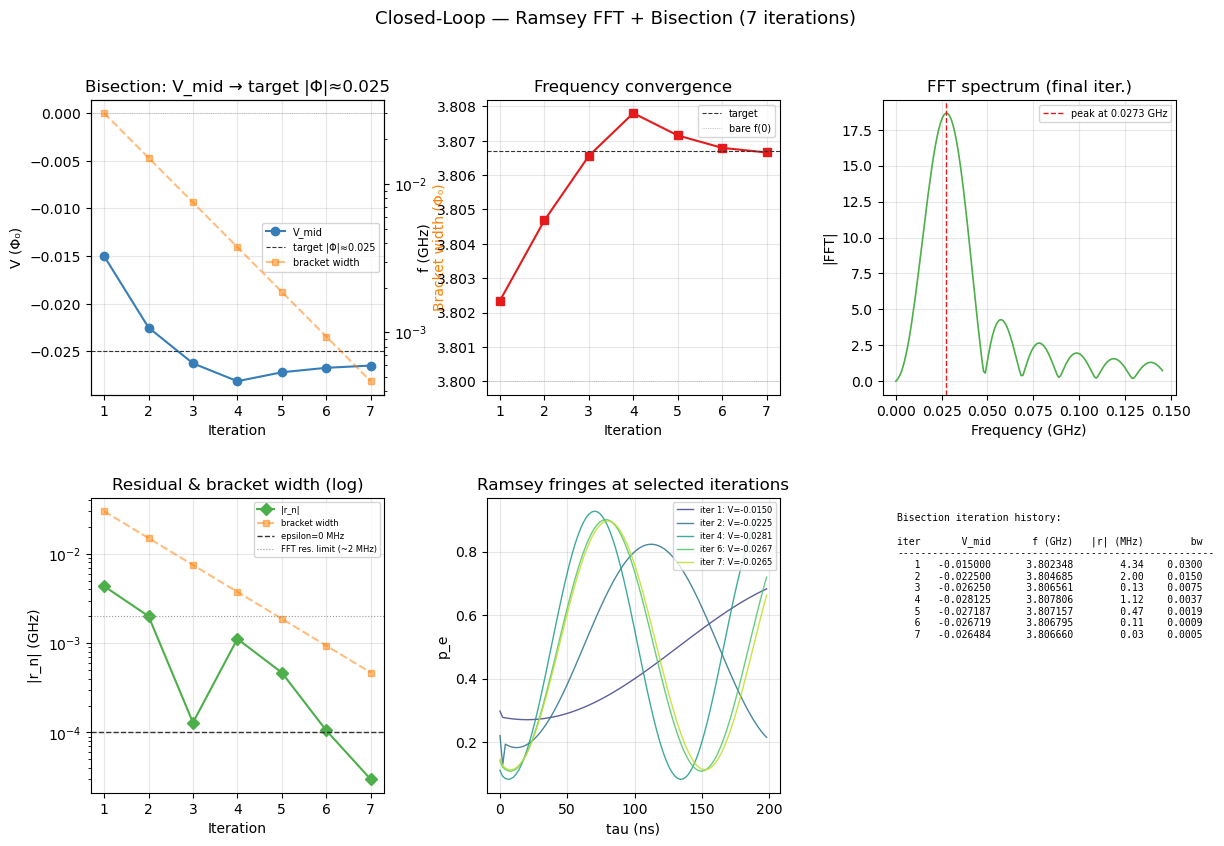

In [31]:
# --- 可视化：Ramsey 二分法闭环收敛过程 ---
history = result_ramsey.fit_params["history"]
n_iters = len(history)

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

# (a) 收敛轨迹 — V_n & bracket 宽度 vs iteration
ax = fig.add_subplot(gs[0, 0])
V_vals = [h["V"] for h in history]
bw_vals = [h.get("bracket_width", 0) for h in history]
iters = range(1, n_iters + 1)
ax.plot(iters, V_vals, "o-", color="#377eb8", ms=6, label="V_mid")
ax.axhline(y=-0.025, color="#333333", ls="--", lw=0.8, label="target |Φ|≈0.025")
ax.axhline(y=0, color="#999999", ls=":", lw=0.5)
ax2 = ax.twinx()
ax2.semilogy(iters, bw_vals, "s--", color="#ff7f00", ms=4, alpha=0.5, label="bracket width")
ax.set(xlabel="Iteration", ylabel="V (Φ₀)", title="Bisection: V_mid → target |Φ|≈0.025")
ax2.set_ylabel("Bracket width (Φ₀)", color="#ff7f00")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=7); ax.grid(alpha=0.3)

# (b) 频率收敛 — f_n vs iteration
ax = fig.add_subplot(gs[0, 1])
f_vals = [h["f"] / (2*np.pi) for h in history]
ax.plot(iters, f_vals, "s-", color="#e41a1c", ms=6)
ax.axhline(y=f_target/(2*np.pi), color="#333333", ls="--", lw=0.8, label="target")
ax.axhline(y=f_bare/(2*np.pi), color="#999999", ls=":", lw=0.5, label="bare f(0)")
ax.set(xlabel="Iteration", ylabel="f (GHz)", title="Frequency convergence")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (c) 残差 & 区间宽度衰减
ax = fig.add_subplot(gs[1, 0])
r_vals = np.abs([h["residual"] for h in history]) / (2*np.pi)
ax.semilogy(iters, r_vals, "D-", color="#4daf4a", ms=6, label="|r_n|")
ax.semilogy(iters, bw_vals, "s--", color="#ff7f00", ms=4, alpha=0.5, label="bracket width")
ax.axhline(y=cal_ramsey.epsilon_f/(2*np.pi), color="#333333", ls="--", lw=1, 
           label=f"epsilon={cal_ramsey.epsilon_f/(2*np.pi)*1e3:.0f} MHz")
ax.axhline(y=1/500, color="#999999", ls=":", lw=0.8, label="FFT res. limit (~2 MHz)")
ax.set(xlabel="Iteration", ylabel="|r_n| (GHz)", title="Residual & bracket width (log)")
ax.legend(fontsize=6); ax.grid(alpha=0.3)

# (d) Ramsey 振荡 — 选取几次迭代对比
ax = fig.add_subplot(gs[1, 1])
from qutip import QobjEvo, basis, mesolve
from sqc.control.sequence import create_ramsey_pulse
show_iters = [0] + [i for i in [n_iters//4, n_iters//2, 3*n_iters//4, n_iters-1] if i > 0 and i <= n_iters-1]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(show_iters)))
for hist_idx, c in zip(show_iters, colors):
    V_show = history[hist_idx]["V"] if hist_idx < n_iters else fp["V_opt"]
    label = "iter {}: V={:.4f}".format(hist_idx+1, V_show)
    qubit_viz = TransmonQubit(EC=0.2*2*np.pi, EJ=10.0*2*np.pi, T1=100e3, T2=50e3, flux=0.0, n_levels=2)
    omega_d_viz = qubit_viz.frequency
    tau_short = CONFIG.pulse.make_time(0, 200)
    t_sig_viz = CONFIG.pulse.make_time(0, 30)
    Phi_viz = FluxSignal(type=1 if abs(V_show)>1e-12 else 0, t_list=t_sig_viz, amplitude=float(V_show))
    qubit_viz.qubit_in_mag(Phi_viz, frame=1, omega_d=omega_d_viz)
    psi_e_viz = basis(2, 1)
    t_glob_viz = CONFIG.pulse.t_global.copy()
    p_vals = []
    for tau in tau_short[::4]:
        ctrl = create_ramsey_pulse(CONFIG.pulse.t_rabi.copy(), tau, omega_d=omega_d_viz,
                                   phase1=0.0, phase2=0.0, qubit=qubit_viz)
        ctrl.t_list = ctrl.t_list - ctrl.t_list[0]
        H = QobjEvo(qubit_viz.H_list, tlist=qubit_viz.mag_signal.t_list, order=1) + \
            QobjEvo(ctrl.hamiltonian, tlist=ctrl.t_list, order=1)
        res = mesolve(H, qubit_viz.state, t_glob_viz, [], e_ops=[psi_e_viz*psi_e_viz.dag()])
        p_vals.append(float(res.expect[0][-1]))
    ax.plot(tau_short[::4], p_vals, color=c, lw=1, label=label, alpha=0.85)
ax.set(xlabel="tau (ns)", ylabel="p_e", title="Ramsey fringes at selected iterations")
ax.legend(fontsize=6); ax.grid(alpha=0.3)

# (e) FFT 频谱（最终迭代）
ax = fig.add_subplot(gs[0, 2])
from numpy.fft import rfft, rfftfreq
n_fft_val = 2048
dt_tau_val = float(tau_short[1] - tau_short[0])
p_last = np.array(p_vals)
p_centered = p_last - np.mean(p_last)
fft_mag = np.abs(rfft(p_centered, n=n_fft_val))
freqs_fft_val = rfftfreq(n_fft_val, d=dt_tau_val)
ax.plot(freqs_fft_val[:150], fft_mag[:150], color="#4daf4a", lw=1.2)
peak_idx = np.argmax(fft_mag[:150])
ax.axvline(x=freqs_fft_val[peak_idx], color="#e41a1c", ls="--", lw=1,
           label="peak at {:.4f} GHz".format(freqs_fft_val[peak_idx]))
ax.set(xlabel="Frequency (GHz)", ylabel="|FFT|", title="FFT spectrum (final iter.)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (f) 迭代表
ax = fig.add_subplot(gs[1, 2])
ax.axis("off")
table_text = "Bisection iteration history:\n\n"
table_text += "{:>4s}  {:>10s}  {:>12s}  {:>10s}  {:>8s}\n".format(
    "iter", "V_mid", "f (GHz)", "|r| (MHz)", "bw")
table_text += "-" * 54 + "\n"
for h in history:
    table_text += "{:4d}  {:10.6f}  {:12.6f}  {:10.2f}  {:8.4f}\n".format(
        h["iter"], h["V"], h["f"]/(2*np.pi),
        abs(h["residual"])/(2*np.pi)*1e3, h.get("bracket_width", 0))
ax.text(0.05, 0.95, table_text, transform=ax.transAxes, fontsize=7,
        verticalalignment="top", fontfamily="monospace")

fig.suptitle("Closed-Loop — Ramsey FFT + Bisection ({} iterations)".format(n_iters), fontsize=13, y=0.98)
plt.show()

## 3. 闭环反馈 — 方法 B：Transient 核函数频率测量

使用正交 Ramsey 读出（$R_y$–$R_x$ 和 $R_y$–$R_{-x}$），$\tau=0$：
$$
p_{diff} = \frac{p_x - p_{-x}}{2}, \quad \delta\omega = \frac{p_{diff}}{G_\alpha}, \quad G_\alpha = \int k(t) dt
$$

与 Ramsey FFT 不同，transient 方法只需要**两次单点测量**即可得到频率，时间开销远小于扫描 $\tau$。

In [ ]:
# --- 闭环标定：transient 测量 + 二分法 ---
qubit2 = TransmonQubit(
    EC=0.2 * 2 * np.pi,
    EJ=10.0 * 2 * np.pi,
    T1=100.0e3,
    T2=50.0e3,
    flux=0.0,
    n_levels=2,
)

cal_transient = SinglePointFrequencyCalibration(
    qubit=qubit2,
    measure_method="transient",
    step_method="bisection",          # 二分法 → 清晰迭代趋势
    f_target=f_target,
    epsilon_f=1e-4 * 2 * np.pi,      # 0.1 MHz tolerance
    V_a=V_a,
    V_b=V_b,
    max_iter=20,
)

print("Starting closed-loop calibration (transient, bisection)...")
result_transient = cal_transient.calibrate()

fp2 = result_transient.fit_params
print(f"\n--- Results ---")
print(f"Converged: {fp2['converged']}")
print(f"Iterations: {fp2['n_iter']}")
print(f"Optimal V: {fp2['V_opt']:.6f} Φ₀ (target: ~0.025)")
print(f"Final f: {result_transient.outputs[0]/(2*np.pi):.6f} GHz")
print(f"Residual: {fp2['residual']/(2*np.pi)*1e3:.3f} MHz")

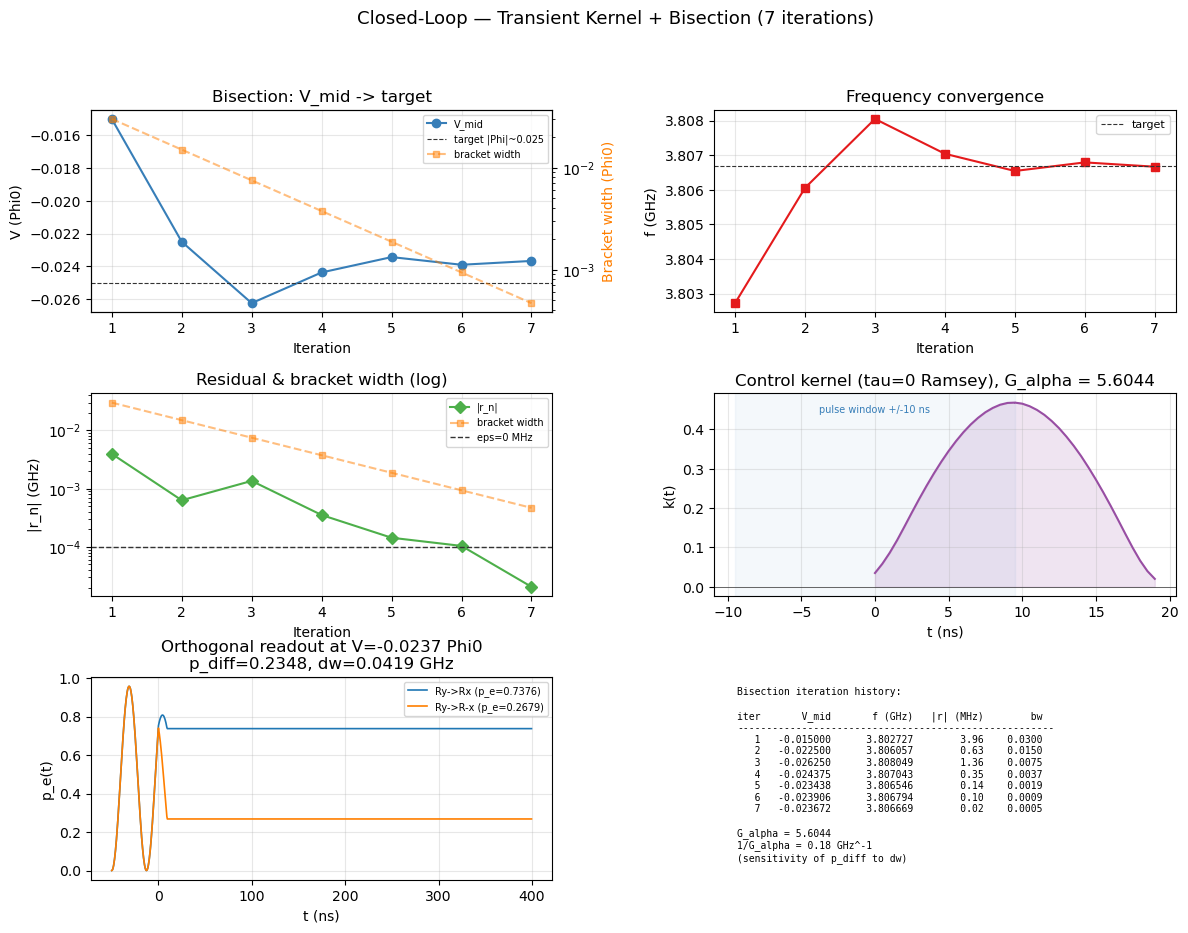

In [33]:
# --- 可视化：Transient 二分法闭环收敛过程 ---
history2 = result_transient.fit_params["history"]
n_iters2 = len(history2)

fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35)

# (a) 收敛轨迹 + bracket width
ax = fig.add_subplot(gs[0, 0])
V_vals2 = [h["V"] for h in history2] if history2 else [fp2["V_opt"]]
bw_vals2 = [h.get("bracket_width", 0) for h in history2] if history2 else [0]
iters2 = range(1, n_iters2 + 1) if history2 else [0]
ax.plot(iters2, V_vals2, "o-", color="#377eb8", ms=6, label="V_mid")
ax.axhline(y=-0.025, color="#333333", ls="--", lw=0.8, label="target |Phi|~0.025")
ax2 = ax.twinx()
ax2.semilogy(iters2, bw_vals2, "s--", color="#ff7f00", ms=4, alpha=0.5, label="bracket width")
ax.set(xlabel="Iteration", ylabel="V (Phi0)", title="Bisection: V_mid -> target")
ax2.set_ylabel("Bracket width (Phi0)", color="#ff7f00")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=7); ax.grid(alpha=0.3)

# (b) 频率收敛
ax = fig.add_subplot(gs[0, 1])
f_vals2 = [h["f"] / (2*np.pi) for h in history2] if history2 else [result_transient.outputs[0]/(2*np.pi)]
ax.plot(iters2, f_vals2, "s-", color="#e41a1c", ms=6)
ax.axhline(y=f_target/(2*np.pi), color="#333333", ls="--", lw=0.8, label="target")
ax.set(xlabel="Iteration", ylabel="f (GHz)", title="Frequency convergence")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (c) 残差 & 区间宽度衰减
ax = fig.add_subplot(gs[1, 0])
r_vals2 = np.abs([h["residual"] for h in history2]) / (2*np.pi) if history2 else [abs(fp2["residual"])/(2*np.pi)]
ax.semilogy(iters2, r_vals2, "D-", color="#4daf4a", ms=6, label="|r_n|")
ax.semilogy(iters2, bw_vals2, "s--", color="#ff7f00", ms=4, alpha=0.5, label="bracket width")
ax.axhline(y=cal_transient.epsilon_f/(2*np.pi), color="#333333", ls="--", lw=1,
           label="eps={:.0f} MHz".format(cal_transient.epsilon_f/(2*np.pi)*1e3))
ax.set(xlabel="Iteration", ylabel="|r_n| (GHz)", title="Residual & bracket width (log)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (d) 核函数可视化
ax = fig.add_subplot(gs[1, 1])
from sqc.control.sequence import create_ramsey_pulse
t_rabi = cal_transient.t_rabi
ctrl_demo = create_ramsey_pulse(
    t_rabi, tau=0.0, omega_d=qubit2.frequency,
    phase1=np.pi/2, phase2=0.0, qubit=qubit2,
)
ctrl_demo.get_kernel(qubit2)
kernel_demo = np.array(ctrl_demo.kernel)
t_kernel = np.array(ctrl_demo.t_samples)
G_demo = float(np.trapezoid(kernel_demo, t_kernel))
ax.plot(t_kernel, kernel_demo, color="#984ea3", lw=1.5)
ax.fill_between(t_kernel, 0, kernel_demo, alpha=0.15, color="#984ea3")
ax.axhline(y=0, color="#333333", ls="-", lw=0.5)
pulse_dur = 2 * t_rabi[-1]
ax.axvspan(-pulse_dur/2, pulse_dur/2, alpha=0.05, color="#377eb8")
y_top = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
ax.text(0, y_top*0.9, "pulse window +/-{:.0f} ns".format(pulse_dur/2),
        ha="center", fontsize=7, color="#377eb8")
ax.set(xlabel="t (ns)", ylabel="k(t)",
       title="Control kernel (tau=0 Ramsey), G_alpha = {:.4f}".format(G_demo))
ax.grid(alpha=0.3)

# (e) 正交读出示意（最终迭代的 flux 处）
ax = fig.add_subplot(gs[2, 0])
from qutip import QobjEvo, basis, mesolve
V_last = V_vals2[-1] if V_vals2 else fp2["V_opt"]
t_sig = CONFIG.pulse.make_time(0, 30)
Phi_last = FluxSignal(type=1 if abs(V_last) > 1e-12 else 0, t_list=t_sig, amplitude=float(V_last))
qubit2.qubit_in_mag(Phi_last, frame=1, omega_d=qubit2.frequency)
t_global = CONFIG.pulse.t_global.copy()
psi_e = basis(2, 1)
H_base = QobjEvo(qubit2.H_list, tlist=qubit2.mag_signal.t_list, order=1)
p_final = {}
for phase2, label, color in [(0.0, "Ry->Rx", "#1f77b4"), (np.pi, "Ry->R-x", "#ff7f00")]:
    ctrl = create_ramsey_pulse(t_rabi, tau=0.0, omega_d=qubit2.frequency,
                               phase1=np.pi/2, phase2=phase2, qubit=qubit2)
    ctrl.t_list = ctrl.t_list - t_rabi[-1]
    H = H_base + QobjEvo(ctrl.hamiltonian, tlist=ctrl.t_list, order=1)
    res = mesolve(H, qubit2.state, t_global, [], e_ops=[psi_e * psi_e.dag()])
    p_final[label] = float(res.expect[0][-1])
    ax.plot(t_global, res.expect[0], color=color, lw=1.2,
            label="{} (p_e={:.4f})".format(label, p_final[label]))
p_diff = (p_final["Ry->Rx"] - p_final["Ry->R-x"]) / 2
ax.set(xlabel="t (ns)", ylabel="p_e(t)",
       title="Orthogonal readout at V={:.4f} Phi0\np_diff={:.4f}, dw={:.4f} GHz".format(
           V_last, p_diff, p_diff/G_demo))
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (f) 迭代表
ax = fig.add_subplot(gs[2, 1])
ax.axis("off")
table_text2 = "Bisection iteration history:\n\n"
table_text2 += "{:>4s}  {:>10s}  {:>12s}  {:>10s}  {:>8s}\n".format(
    "iter", "V_mid", "f (GHz)", "|r| (MHz)", "bw")
table_text2 += "-" * 54 + "\n"
for h in history2:
    table_text2 += "{:4d}  {:10.6f}  {:12.6f}  {:10.2f}  {:8.4f}\n".format(
        h["iter"], h["V"], h["f"]/(2*np.pi),
        abs(h["residual"])/(2*np.pi)*1e3, h.get("bracket_width", 0))
table_text2 += "\nG_alpha = {:.4f}\n".format(G_demo)
table_text2 += "1/G_alpha = {:.2f} GHz^-1\n".format(1/G_demo)
table_text2 += "(sensitivity of p_diff to dw)"
ax.text(0.05, 0.95, table_text2, transform=ax.transAxes, fontsize=7,
        verticalalignment="top", fontfamily="monospace")

fig.suptitle("Closed-Loop — Transient Kernel + Bisection ({} iterations)".format(n_iters2),
             fontsize=13, y=0.98)
plt.show()

## 4. 两种方法对比

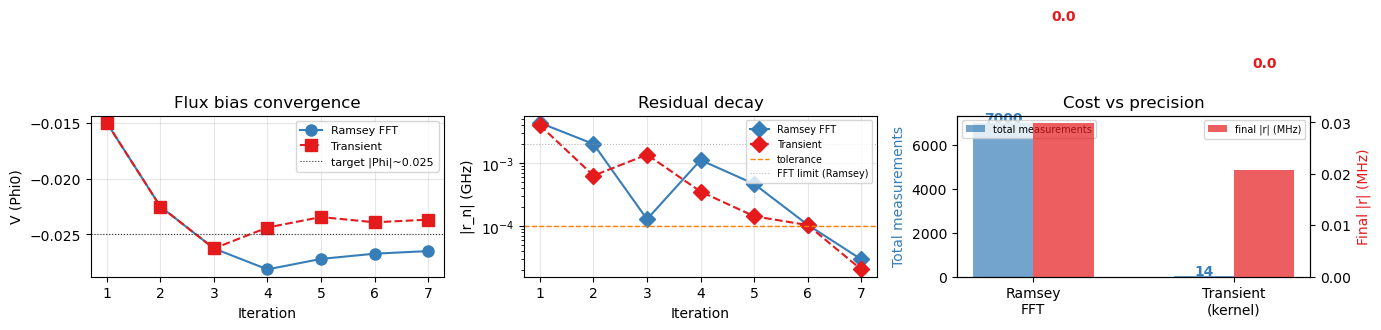


SUMMARY - Closed-Loop Frequency Calibration
Target frequency: 3.806690 GHz (Phi ~ 0.025 Phi0)
Bare frequency:   3.800000 GHz (Phi = 0)
Detuning:         6.7 MHz
----------------------------------------------------------------------
Method                Iter   Total meas      Final |r|      V_opt
----------------------------------------------------------------------
Ramsey FFT               7         7000         0.03 MHz  -0.026484
Transient kernel         7           14         0.02 MHz  -0.023672
----------------------------------------------------------------------

Key conclusions:
1. Closed-loop calibration needs no analytical f(Phi) model.
2. Bisection gives exponential bracket-width halving per iteration.
3. Ramsey FFT precision limited by tau scan range (df ~ 1/T_max ~ 2 MHz).
4. Transient kernel: only 2 measurements/iter (vs 1000 tau points).
5. Hybrid strategy: transient for fast coarse tune + Ramsey for fine verification.


In [34]:
# --- 并排对比 ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

V1 = np.array([h["V"] for h in history]) if history else np.array([fp["V_opt"]])
V2 = np.array([h["V"] for h in history2]) if history2 else np.array([fp2["V_opt"]])
r1 = np.abs([h["residual"] for h in history]) / (2*np.pi) if history else [abs(fp["residual"])/(2*np.pi)]
r2 = np.abs([h["residual"] for h in history2]) / (2*np.pi) if history2 else [abs(fp2["residual"])/(2*np.pi)]

# (a) V 收敛对比
ax = axes[0]
ax.plot(range(1, len(V1)+1), V1, "o-", color="#377eb8", ms=8, label="Ramsey FFT")
ax.plot(range(1, len(V2)+1), V2, "s--", color="#e41a1c", ms=8, label="Transient")
ax.axhline(y=-0.025, color="#333333", ls=":", lw=0.8, label="target |Phi|~0.025")
ax.set(xlabel="Iteration", ylabel="V (Phi0)", title="Flux bias convergence")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (b) 残差对比
ax = axes[1]
ax.semilogy(range(1, len(r1)+1), r1, "D-", color="#377eb8", ms=8, label="Ramsey FFT")
ax.semilogy(range(1, len(r2)+1), r2, "D--", color="#e41a1c", ms=8, label="Transient")
ax.axhline(y=cal_ramsey.epsilon_f/(2*np.pi), color="#ff7f00", ls="--", lw=1, label="tolerance")
ax.axhline(y=1/500, color="#999999", ls=":", lw=0.8, alpha=0.7, label="FFT limit (Ramsey)")
ax.set(xlabel="Iteration", ylabel="|r_n| (GHz)", title="Residual decay")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (c) 效率对比
ax = axes[2]
methods = ["Ramsey\nFFT", "Transient\n(kernel)"]
n_meas_per_iter = [len(cal_ramsey.tau_list), 2]
n_iters = [result_ramsey.fit_params["n_iter"], result_transient.fit_params["n_iter"]]
total_meas = [max(1, n_meas_per_iter[0]) * max(1, n_iters[0]),
              max(1, n_meas_per_iter[1]) * max(1, n_iters[1])]
final_err = [
    abs(result_ramsey.fit_params["residual"]) / (2*np.pi) * 1e3,
    abs(result_transient.fit_params["residual"]) / (2*np.pi) * 1e3,
]
x = np.arange(len(methods))
width = 0.3
ax.bar(x - width/2, total_meas, width, color="#377eb8", alpha=0.7, label="total measurements")
ax2 = ax.twinx()
ax2.bar(x + width/2, final_err, width, color="#e41a1c", alpha=0.7, label="final |r| (MHz)")
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel("Total measurements", color="#377eb8")
ax2.set_ylabel("Final |r| (MHz)", color="#e41a1c")
ax.set_title("Cost vs precision")
for i, (tm, fe) in enumerate(zip(total_meas, final_err)):
    ax.text(i - width/2, tm + 50, str(tm), ha="center", fontsize=10, fontweight="bold", color="#377eb8")
    ax2.text(i + width/2, fe + 0.02, "{:.1f}".format(fe), ha="center", fontsize=10, fontweight="bold", color="#e41a1c")
ax.legend(loc="upper left", fontsize=7)
ax2.legend(loc="upper right", fontsize=7)
fig.tight_layout(); plt.show()

# --- 总结表 ---
print("\n" + "="*70)
print("SUMMARY - Closed-Loop Frequency Calibration")
print("="*70)
print("Target frequency: {:.6f} GHz (Phi ~ 0.025 Phi0)".format(f_target/(2*np.pi)))
print("Bare frequency:   {:.6f} GHz (Phi = 0)".format(f_bare/(2*np.pi)))
print("Detuning:         {:.1f} MHz".format((f_target-f_bare)/(2*np.pi)*1e3))
print("-"*70)
print("{:<20s} {:>5s} {:>12s} {:>14s} {:>10s}".format(
    "Method", "Iter", "Total meas", "Final |r|", "V_opt"))
print("-"*70)
print("{:<20s} {:>5d} {:>12d} {:>12.2f} MHz {:>10.6f}".format(
    "Ramsey FFT", n_iters[0], total_meas[0], final_err[0], V1[-1]))
print("{:<20s} {:>5d} {:>12d} {:>12.2f} MHz {:>10.6f}".format(
    "Transient kernel", n_iters[1], total_meas[1], final_err[1], V2[-1]))
print("-"*70)
print("\nKey conclusions:")
print("1. Closed-loop calibration needs no analytical f(Phi) model.")
print("2. Bisection gives exponential bracket-width halving per iteration.")
print("3. Ramsey FFT precision limited by tau scan range (df ~ 1/T_max ~ 2 MHz).")
print("4. Transient kernel: only 2 measurements/iter (vs {} tau points).".format(n_meas_per_iter[0]))
print("5. Hybrid strategy: transient for fast coarse tune + Ramsey for fine verification.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
AWG sample_rate = 2.0 GSa/s  →  dt = 0.5 ns
t_rabi  : start=0.00  end=9.50  N=20
t_global: start=-50.00  end=399.50  N=900
tau_list: N=500
Transmon defaults: EC/h=0.2 GHz, EJ/h=15.0 GHz
Distortion: amp=0.300, tau=30.0 ns (initial drive = 70% of nominal)
freq=2.839 GHz, sensitivity=-6.752 GHz/Phi0
cal: kind=phi_h, h in [-0.030,0.030], phi in [125.682,-143.662] rad
trunc_list: [99.5 99.  98.5 98.  97.5 97.  96.5 96.  95.5 95.  94.5 94.  93.5 93.
 92.5 92.  91.5 91.  90.5 90.  89.5 89.  88.5 88.  87.5 87.  86.5 86.
 85.5 85.  84.5 84.  83.5 83.  82.5 82.  81.5 81.  80.5 80.  79.5 79.
 78.5 78.  77.5 77.  76.5 76.  75.5 75.  74.5 74.  73.5 73.  72.5 72.
 71.5 71.  70.5 70.  69.5 69.  68.5 68.  67.5 67.  66.5 66.  65.5 65.
 64.5 64.  63.5 63.  62.5 62.  61.5 61.  60.5 60.  59.5 59.  58.5 58.
 57.5 57.  56.5 56.  55.5 55.  54.5 54.  53.5 53.  52.5 52.  51.5 51.
 50.5 50.  49.5 49.  48.5 48.  47.5 47.  46.

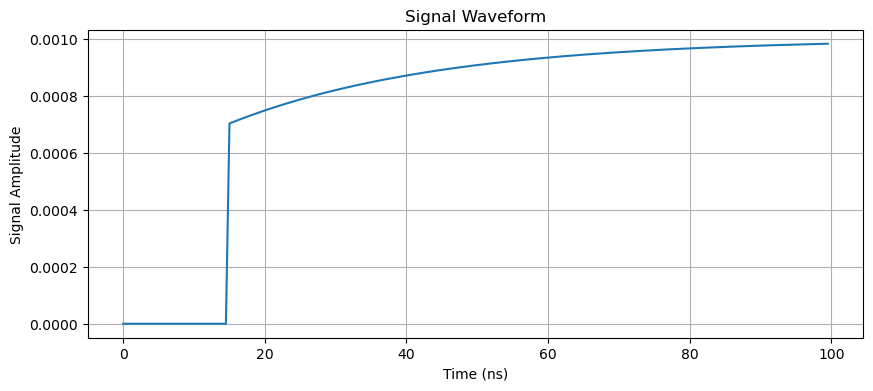

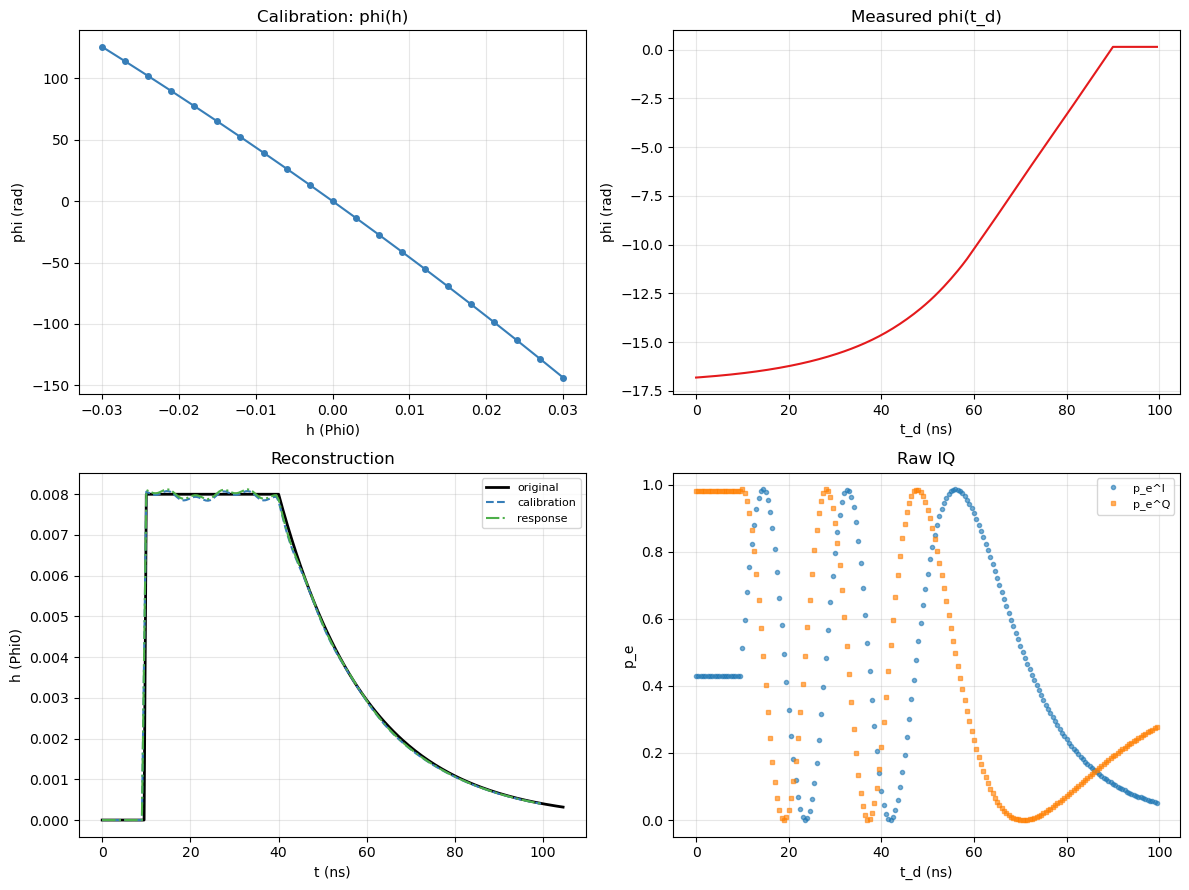

In [ ]:

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from sqc.config import CONFIG
from sqc.devices.transmon import TransmonQubit
from sqc.control.flux_signal import FluxSignal

print(f"AWG sample_rate = {CONFIG.awg.sample_rate} GSa/s  →  dt = {CONFIG.awg.dt} ns")
print(f"t_rabi  : start={CONFIG.pulse.t_rabi[0]:.2f}  end={CONFIG.pulse.t_rabi[-1]:.2f}  N={len(CONFIG.pulse.t_rabi)}")
print(f"t_global: start={CONFIG.pulse.t_global[0]:.2f}  end={CONFIG.pulse.t_global[-1]:.2f}  N={len(CONFIG.pulse.t_global)}")
print(f"tau_list: N={len(CONFIG.pulse.tau_list)}")
print(f"Transmon defaults: EC/h={CONFIG.transmon.EC} GHz, EJ/h={CONFIG.transmon.EJ} GHz")
# === Cryoscope: 标定 → 测量 → 重建 ===
from sqc.reconstruction.cryoscope import CryoscopeCalibration
from sqc.experiments.cryoscope import CryoscopeExperiment
from sqc.reconstruction.cryoscope import CryoscopeReconstruction

# ---- qubit（最优灵敏度工作点）----
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=np.arctan(np.sqrt(2)) / np.pi,
    n_levels=3,
)


# === 10.0 全局设置：qubit + 失真模型 + 控制线 ===
from sqc.config import CONFIG
from sqc.devices.transmon import TransmonQubit
from sqc.control.flux_signal import FluxSignal
from sqc.control.waveform import Waveform
from sqc.hardware.distortion import (
    SingleExponentialDistortion,
    MultiExponentialDistortion,
)
from sqc.hardware.control_line import ControlLine
from sqc.calibration.waveform import PredistortionDesigner, WaveformCalibration
from sqc.workflows.predistortion_validation import PredistortionValidationWorkflow

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from qutip import basis, mesolve, sigmax, sigmaz, QobjEvo
# --- 失真模型：故意夸大以保证可视化清晰 ---
# 真实系统中 amp 通常 1-10%; 这里用 30% 让 Chevron 失真肉眼可见
dist = SingleExponentialDistortion(amplitude=0.3, tau=30.0)
print(f"Distortion: amp={dist.amplitude:.3f}, tau={dist.tau:.1f} ns "
      f"(initial drive = {1-dist.amplitude:.0%} of nominal)")

# 失真模型的阶跃响应（理论真值）
t_step = CONFIG.pulse.make_time(0, 200)
s_true = dist.step_response(t_step)

# 建立控制线
line = ControlLine(
    name="Z0", kind="z", source="AWG0:CH0", target="Q0",
    transfer_function=dist,
)

# --- 选择 step 幅度，使得 Ramsey 相位 |φ| < π （避免 wrap）---
# φ_max = 2π·|κ|·step_amp·τ；取 τ=50 ns 则 step_amp < 1/(2·|κ|·τ) ≈ 0.0019 Φ₀
step_amp = 0.001  # Φ₀
#print(f"Step amplitude: {step_amp} Φ₀ → φ_max ≈ {2*np.pi*abs(kappa_cryo)*step_amp*50:.2f} rad (within ±π)")

# --- 阶跃信号 + 失真 → 片上真实磁通 ---
t_flux = CONFIG.pulse.make_time(0, 100)
step_raw = np.where(t_flux >= 15, step_amp, 0.0)
step_wf = Waveform(t_list=t_flux, samples=step_raw)
on_chip_wf = line.apply(step_wf)
on_chip_flux = FluxSignal(type=8, t_list=t_flux, signal=on_chip_wf.samples)

on_chip_flux.plot()
print(f"freq={qubit.frequency/(2*np.pi):.3f} GHz, sensitivity={qubit.frequency_sensitivity(qubit.flux)/(2*np.pi):.3f} GHz/Phi0")

tau_R = 10.0
t_list = CONFIG.pulse.make_time(0, 105)
sig = np.zeros(len(t_list))
sig[(t_list >= 10) & (t_list <= 40)] = 0.008
sig[t_list > 40] = 0.008 * np.exp(-(t_list[t_list > 40] - 40) / 20)
test_flux = FluxSignal(type=8, t_list=t_list, signal=sig)

# ---- Step 1: 标定 ----
h_list = np.linspace(-0.03, 0.03, 21)
cal = CryoscopeCalibration(qubit=qubit, h_list=h_list, tau=105.0)
cal_table = cal.calibrate()
print(f"cal: kind={cal_table.kind}, h in [{cal_table.inputs[0]:.3f},{cal_table.inputs[-1]:.3f}], phi in [{cal_table.outputs[0]:.3f},{cal_table.outputs[-1]:.3f}] rad")

# ---- Step 2: 测量 ----
trunc_list = CONFIG.pulse.make_time(0, 100)[::-1]  # ns
test_signal = FluxSignal(type=7, t_list=CONFIG.pulse.make_time(0, 105), amplitude=0.005, center=40, width=5)
cryo_exp = CryoscopeExperiment(qubit=qubit, flux_signal=test_flux, tau=105.0, trunc_list=trunc_list)
meas = cryo_exp.run()

# ---- Step 3: 重建（两种 inversion 对比）----
recon_cal = CryoscopeReconstruction(calibration=cal_table, tau=105.0, inversion="calibration")
recon_resp = CryoscopeReconstruction(qubit=qubit, tau=105.0, inversion="response")
h_cal = recon_cal.reconstruct(meas)
h_resp = recon_resp.reconstruct(meas)

# ---- 可视化 ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0,0].plot(cal_table.inputs, cal_table.outputs, "o-", color="#377eb8", ms=4)
axes[0,0].set(xlabel="h (Phi0)", ylabel="phi (rad)", title="Calibration: phi(h)"); axes[0,0].grid(alpha=0.3)

trunc_inc = meas.axes["trunc"][::-1]  # axis stored decreasing
axes[0,1].plot(trunc_inc, meas.data["varphi"], color="#e41a1c")
axes[0,1].set(xlabel="t_d (ns)", ylabel="phi (rad)", title="Measured phi(t_d)"); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(test_flux.t_list, test_flux.signal, "k-", lw=2, label="original")
axes[1,0].plot(h_cal.t_list, h_cal.signal, "--", color="#377eb8", label="calibration")
axes[1,0].plot(h_resp.t_list, h_resp.signal, "-.", color="#4daf4a", label="response")
axes[1,0].set(xlabel="t (ns)", ylabel="h (Phi0)", title="Reconstruction"); axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(trunc_inc, meas.data["p_e_I"], "o", color="#1f77b4", ms=3, alpha=0.6, label="p_e^I")
axes[1,1].plot(trunc_inc, meas.data["p_e_Q"], "s", color="#ff7f00", ms=3, alpha=0.6, label="p_e^Q")
axes[1,1].set(xlabel="t_d (ns)", ylabel="p_e", title="Raw IQ"); axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)
fig.tight_layout(); plt.show()


Distortion: amp=0.300, tau=30.0 ns (initial drive = 70% of nominal)
qubit frequency: 23.75209505361109
Optimal work point flux: 0.9553166181245093
Sliding measurement with 208 samples took 1.11 seconds
Sliding measurement with 208 samples took 1.05 seconds


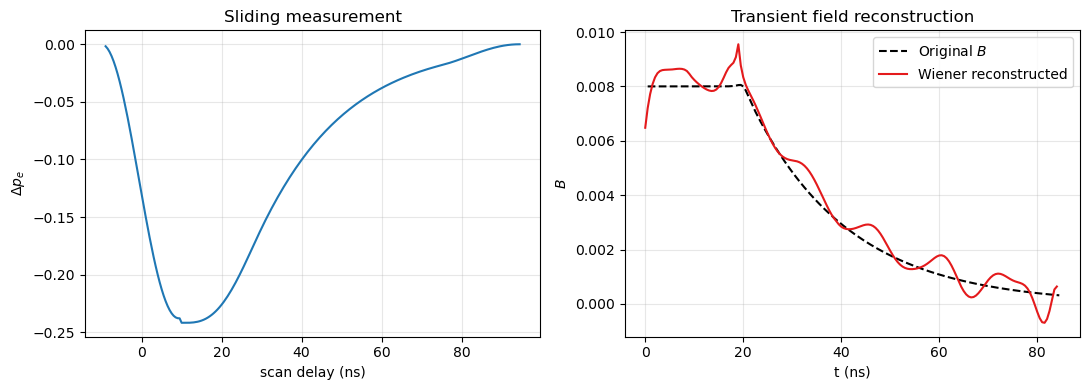

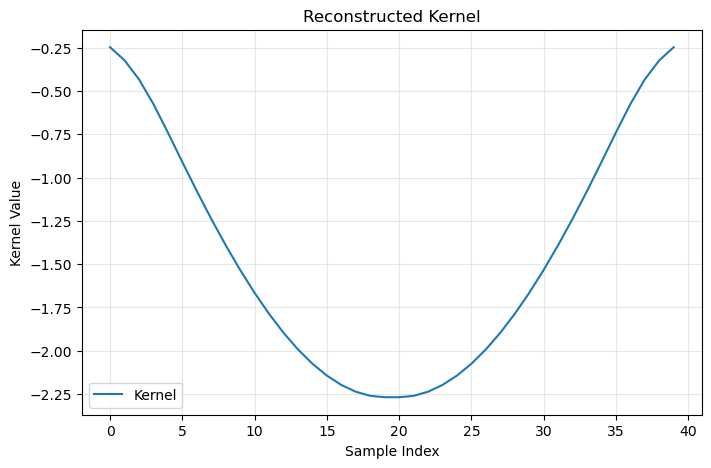

In [ ]:
from sqc.experiments.transient import TransientSensingExperiment
from sqc.reconstruction.transient import TransientReconstruction

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=0.9553, n_levels=2,
)


# === 10.0 全局设置：qubit + 失真模型 + 控制线 ===
from sqc.config import CONFIG
from sqc.devices.transmon import TransmonQubit
from sqc.control.flux_signal import FluxSignal
from sqc.control.waveform import Waveform
from sqc.hardware.distortion import (
    SingleExponentialDistortion,
    MultiExponentialDistortion,
)
from sqc.hardware.control_line import ControlLine
from sqc.calibration.waveform import PredistortionDesigner, WaveformCalibration
from sqc.workflows.predistortion_validation import PredistortionValidationWorkflow

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from qutip import basis, mesolve, sigmax, sigmaz, QobjEvo
# --- 失真模型：故意夸大以保证可视化清晰 ---
# 真实系统中 amp 通常 1-10%; 这里用 30% 让 Chevron 失真肉眼可见
dist = SingleExponentialDistortion(amplitude=0.3, tau=30.0, smooth = True)
print(f"Distortion: amp={dist.amplitude:.3f}, tau={dist.tau:.1f} ns "
      f"(initial drive = {1-dist.amplitude:.0%} of nominal)")

# 失真模型的阶跃响应（理论真值）
t_step = CONFIG.pulse.make_time(0, 200)
s_true = dist.step_response(t_step)

# 建立控制线
line = ControlLine(
    name="Z0", kind="z", source="AWG0:CH0", target="Q0",
    transfer_function=dist,
)

# --- 选择 step 幅度，使得 Ramsey 相位 |φ| < π （避免 wrap）---
# φ_max = 2π·|κ|·step_amp·τ；取 τ=50 ns 则 step_amp < 1/(2·|κ|·τ) ≈ 0.0019 Φ₀
step_amp = 0.001  # Φ₀
#print(f"Step amplitude: {step_amp} Φ₀ → φ_max ≈ {2*np.pi*abs(kappa_cryo)*step_amp*50:.2f} rad (within ±π)")

# --- 阶跃信号 + 失真 → 片上真实磁通 ---
t_flux = CONFIG.pulse.make_time(0, 50)
step_raw = np.where(t_flux >= 15, step_amp, 0.0)
step_wf = Waveform(t_list=t_flux, samples=step_raw)
on_chip_wf = line.apply(step_wf)
on_chip_flux = FluxSignal(type=8, t_list=t_flux, signal=on_chip_wf.samples)

import numpy as np
from scipy.special import expit

tau_R = 10.0
t_list = CONFIG.pulse.make_time(0, 105)

def smooth_step(t, t0, width=2.0):
    """在t0处用sigmoid实现平滑阶跃，width控制过渡宽度"""
    return expit((t - t0) / (width / 4))

# 上升沿和下降沿的sigmoid
rise = smooth_step(t_list, 10, width=2.0)   # 在10处从0→1
fall = smooth_step(t_list, 40, width=2.0)   # 在40处从0→1

# 平台部分的值（在40之前为0.008，40处平滑过渡到指数衰减）
platform_value = 0.008 * (1 - fall)  # 在40之前为0.008，40之后平滑降到0

# 指数衰减部分（在40处平滑开启）
decay_value = 0.008 * np.exp(-(t_list - 40) / 20) * fall  # 在40处从0平滑开启

# 最终信号 = 平台部分 + 衰减部分
sig = rise * (platform_value + decay_value)

mask = t_list > 20

t_list = t_list[mask] - 20
sig = sig[mask]
test_flux = FluxSignal(type=8, t_list=t_list, signal=sig)

# freq
print(f"qubit frequency: {qubit.frequency}")
print(f"Optimal work point flux: {qubit.optimal_work_point()}")
trans_exp = TransientSensingExperiment(qubit=qubit, flux_signal=test_flux)
trans_result = trans_exp.run()
kernel = trans_result.data["kernel"]

rec = TransientReconstruction(method="wiener", lambda_reg=5)
B_rec_signal = rec.reconstruct(trans_result, kernel=trans_result.data["kernel"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(trans_result.axes["scan"], trans_result.data["delta_p"], color="#1f77b4")
axes[0].set_xlabel("scan delay (ns)"); axes[0].set_ylabel(r"$\Delta p_e$")
axes[0].set_title("Sliding measurement"); axes[0].grid(alpha=0.3)

axes[1].plot(trans_result.axes["t_flux"], trans_result.data["flux_samples"], "k--", label="Original $B$")
axes[1].plot(B_rec_signal.t_list, B_rec_signal.signal, color="#e41a1c", label="Wiener reconstructed")
axes[1].set_xlabel("t (ns)"); axes[1].set_ylabel("$B$")
axes[1].set_title("Transient field reconstruction"); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(len(kernel)), kernel, label="Kernel")
plt.xlabel("Sample Index")
plt.ylabel("Kernel Value")
plt.title("Reconstructed Kernel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 闭环预失真标定 — Cryoscope 测量 + 逆滤波器设计 + 验证

完整闭环流程：
1. **前向失真**：阶跃信号 → 控制线失真模型 → 片上真实磁通波形
2. **Cryoscope 测量**：通过量子模拟 Cryoscope 协议测量片上阶跃响应
3. **模型拟合**：从测量数据拟合 `SingleExponentialDistortion` 参数 (amp, τ)
4. **逆滤波器设计**：`PredistortionDesigner` 基于拟合模型设计 IIR 逆滤波器
5. **验证**：AWG 预失真波形 → 控制线失真 → 片上校正波形，与目标对比

理论参考：Gao 2021 §V.E (Cryoscope), Rol 2020 §IV (cascade inverse)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
AWG dt = 0.5 ns
True (unknown to us): amp=0.25, tau=25 ns
  Analytical s(t) = 1 - 0.25·exp(-t/25)
Qubit: f_q = 4.6687 GHz, κ = -1.211 GHz/Φ₀ at flux=0.05

Step signal: amp = 0.0050 Φ₀, step at t = 10 ns
On-chip plateau ≈ 0.004985 Φ₀ (target 0.0050)
Initial jump ≈ 0.003762 Φ₀ (expected 0.0037)


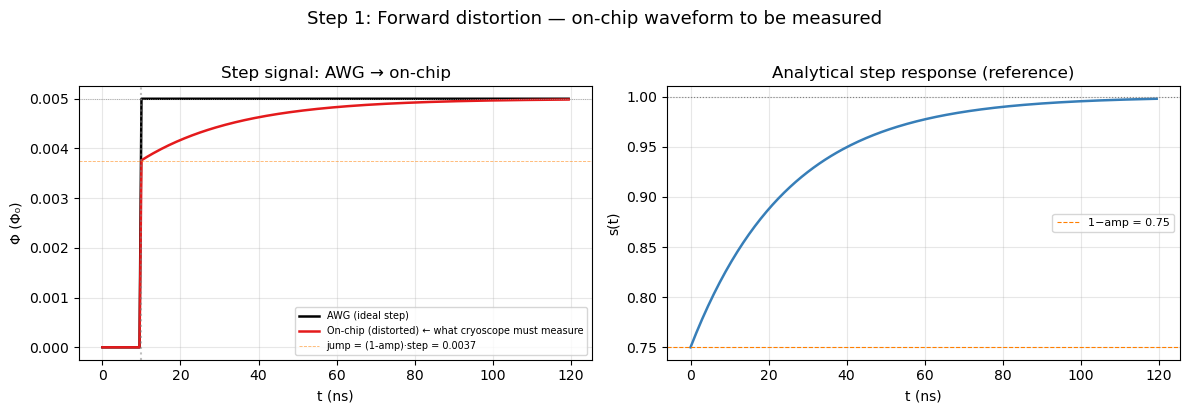

In [30]:
# ═══════════════════════════════════════════════════════════════════════════
# 0. 环境 & 模块导入
# ═══════════════════════════════════════════════════════════════════════════
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit

from sqc.config import CONFIG
from sqc.devices.transmon import TransmonQubit
from sqc.control.flux_signal import FluxSignal
from sqc.control.waveform import Waveform
from sqc.hardware.distortion import (
    SingleExponentialDistortion, CascadeDistortion,
)
from sqc.hardware.control_line import ControlLine
from sqc.calibration.waveform import PredistortionDesigner
from sqc.experiments.cryoscope import CryoscopeExperiment
from sqc.reconstruction.cryoscope import CryoscopeReconstruction
import warnings
warnings.filterwarnings('ignore')

print(f"AWG dt = {CONFIG.awg.dt} ns")

# ═══════════════════════════════════════════════════════════════════════════
# 1. 「硬件」真实失真 + qubit + 控制线
# ═══════════════════════════════════════════════════════════════════════════
# 关键时间约束（Cryoscope 测量有效的前提）：
#   τ_dist << τ_cryo < Ramsey 序列时长上限 (~190 ns)
# 选 τ_dist = 25 ns，τ_cryo = 100 ns → 失真动态完全落在测量窗口内
true_dist = SingleExponentialDistortion(
    amplitude=0.25,   # 25% 指数尾部
    tau=25.0,         # 25 ns 时间常数（快于 cryo_tau）
    smooth=False,
)
print(f"True (unknown to us): amp={true_dist.amplitude:.2f}, tau={true_dist.tau:.0f} ns")
print(f"  Analytical s(t) = 1 - {true_dist.amplitude:.2f}·exp(-t/{true_dist.tau:.0f})")

# qubit 偏置在适度灵敏点
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=15.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=0.05, n_levels=3,
)
f_q = qubit.frequency / (2 * np.pi)
kappa = qubit.frequency_sensitivity(0.05) / (2 * np.pi)
print(f"Qubit: f_q = {f_q:.4f} GHz, κ = {kappa:.3f} GHz/Φ₀ at flux=0.05")

# 控制线（AWG → 失真 → 片上）
line = ControlLine(
    name="Z0", kind="z", source="AWG0:CH0", target="Q0",
    transfer_function=true_dist,
)

# ═══════════════════════════════════════════════════════════════════════════
# 2. AWG 阶跃信号 → 经控制线 → 片上失真波形（ground truth，待测量）
# ═══════════════════════════════════════════════════════════════════════════
step_amp = 0.005  # Φ₀
step_t = 10.0     # 阶跃发生时刻 (ns) — 早一点，给 cryo 足够测量窗口
t_flux = CONFIG.pulse.make_time(0, 120)
step_raw = np.where(t_flux >= step_t, step_amp, 0.0)
step_wf = Waveform(t_list=t_flux, samples=step_raw)

# 前向失真：AWG 理想阶跃 → 控制线失真 → 片上真实磁通
on_chip_uncorrected = line.apply(step_wf)

# 解析阶跃响应（仅用于事后对比，不参与拟合）
t_theory = CONFIG.pulse.make_time(0, 120)
s_theory = true_dist.step_response(t_theory)

print(f"\nStep signal: amp = {step_amp:.4f} Φ₀, step at t = {step_t:.0f} ns")
print(f"On-chip plateau ≈ {on_chip_uncorrected.samples[-1]:.6f} Φ₀ "
      f"(target {step_amp:.4f})")
post_idx = np.argmax(t_flux >= step_t)
print(f"Initial jump ≈ {on_chip_uncorrected.samples[post_idx]:.6f} Φ₀ "
      f"(expected {step_amp*(1-true_dist.amplitude):.4f})")

# ── 可视化前向失真 ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_flux, step_raw, 'k-', lw=1.8, label='AWG (ideal step)')
axes[0].plot(t_flux, on_chip_uncorrected.samples, '#e41a1c', lw=1.8,
             label='On-chip (distorted) ← what cryoscope must measure')
axes[0].axvline(x=step_t, color='gray', ls=':', alpha=0.5)
axes[0].axhline(y=step_amp*(1-true_dist.amplitude), color='#ff7f00',
                ls='--', lw=0.6, alpha=0.6,
                label=f'jump = (1-amp)·step = {step_amp*(1-true_dist.amplitude):.4f}')
axes[0].axhline(y=step_amp, color='#999', ls=':', lw=0.6)
axes[0].set(xlabel='t (ns)', ylabel='Φ (Φ₀)', title='Step signal: AWG → on-chip')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].plot(t_theory, s_theory, '#377eb8', lw=1.8)
axes[1].axhline(y=1.0, color='gray', ls=':', lw=0.8)
axes[1].axhline(y=1 - true_dist.amplitude, color='#ff7f00', ls='--', lw=0.8,
                label=f'1−amp = {1-true_dist.amplitude:.2f}')
axes[1].set(xlabel='t (ns)', ylabel='s(t)',
            title='Analytical step response (reference)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

fig.suptitle('Step 1: Forward distortion — on-chip waveform to be measured',
             fontsize=13, y=1.02)
fig.tight_layout(); plt.show()

Step 2: Cryoscope quantum measurement of the on-chip distortion
Cryoscope τ = 100 ns, 66 truncation points
trunc range: [12.0, 109.5] ns (within Ramsey sequence ~119 ns)
trunc_list: [109.5 108.  106.5 105.  103.5 102.  100.5  99.   97.5  96.   94.5  93.
  91.5  90.   88.5  87.   85.5  84.   82.5  81.   79.5  78.   76.5  75.
  73.5  72.   70.5  69.   67.5  66.   64.5  63.   61.5  60.   58.5  57.
  55.5  54.   52.5  51.   49.5  48.   46.5  45.   43.5  42.   40.5  39.
  37.5  36.   34.5  33.   31.5  30.   28.5  27.   25.5  24.   22.5  21.
  19.5  18.   16.5  15.   13.5  12. ]
Cryoscope simulation: 4.3s

── Distortion parameters ──
True (hidden):     amp = 0.2500, tau = 25.0 ns
Cryoscope fit:     amp = 0.2335, tau = 24.5 ns
Fit error:         Δamp = 0.0165, Δtau = 0.5 ns
Reconstruction RMSE = 4.93e-05 Φ₀


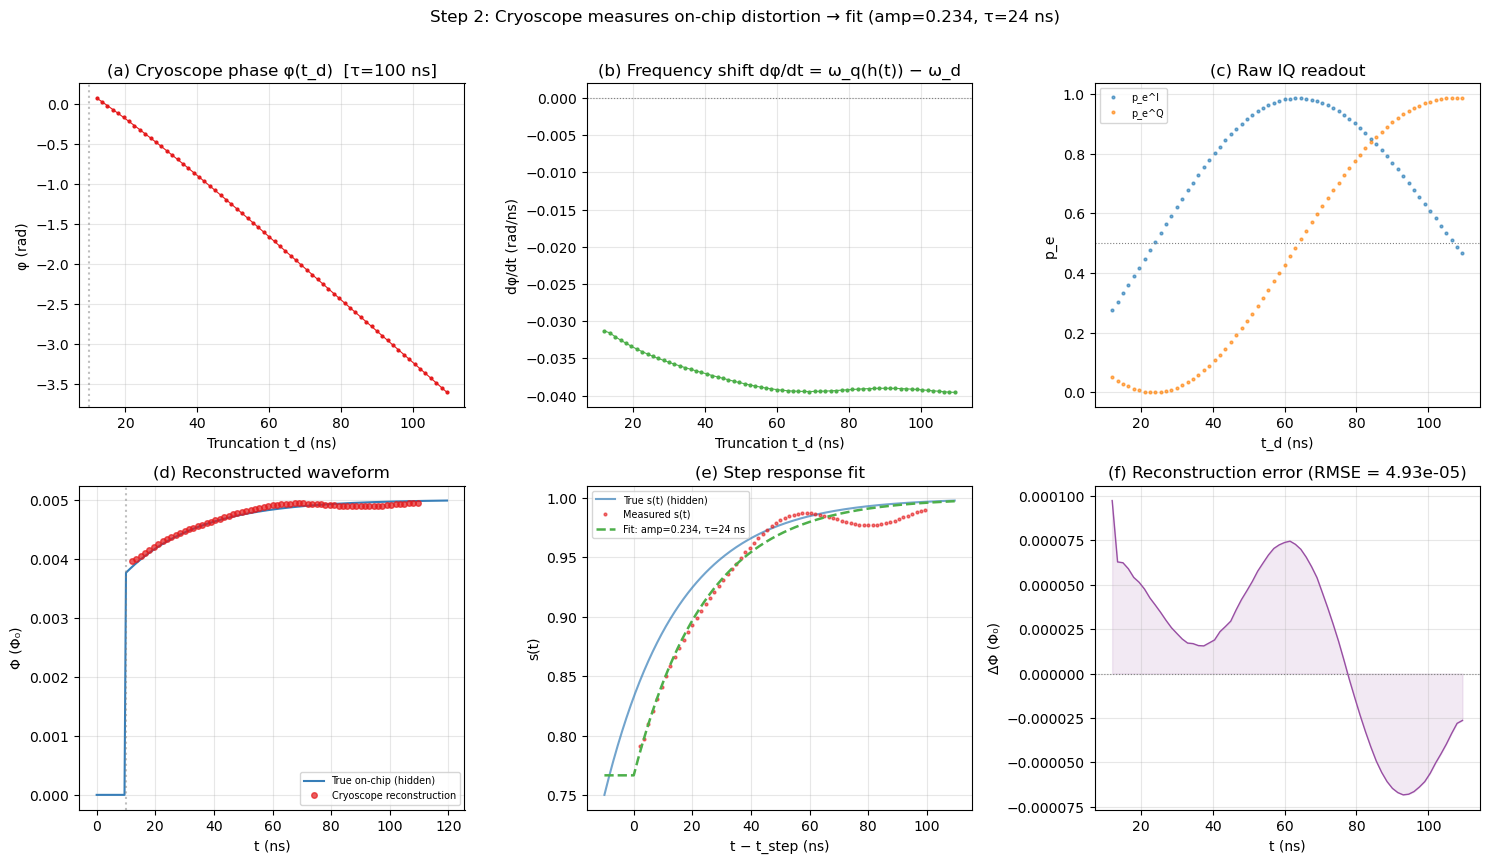

In [31]:
# ═══════════════════════════════════════════════════════════════════════════
# 3. Cryoscope 量子测量片上失真波形 → 重建 → 拟合失真参数
# ═══════════════════════════════════════════════════════════════════════════
# 关键设计：
#   - 把已被失真的片上波形 (on_chip_uncorrected) 作为 cryoscope 的测量目标
#   - cryoscope 不再走 control_line（否则截断沿会被 *再次* 失真，引入二次效应）
#   - cryo_tau = 100 ns 提供足够长的相位累积窗口
#   - trunc_list 限制在 [12, 110] ns 内（< cryo_tau + t_rabi，保证 IQ 读出灵敏度）
print("=" * 64)
print("Step 2: Cryoscope quantum measurement of the on-chip distortion")
print("=" * 64)

import time

CRYO_TAU = 100.0
trunc_list = CONFIG.pulse.make_time(step_t + 2, 110)[::-3]  # 每 3 个点取 1 个
print(f"Cryoscope τ = {CRYO_TAU:.0f} ns, {len(trunc_list)} truncation points")
print(f"trunc range: [{trunc_list[-1]:.1f}, {trunc_list[0]:.1f}] ns "
      f"(within Ramsey sequence ~{2*9.5 + CRYO_TAU:.0f} ns)")

# 用片上失真波形构造 cryoscope 的测量输入信号
on_chip_signal = FluxSignal(
    type=8, t_list=t_flux, signal=on_chip_uncorrected.samples,
)

t0 = time.time()
cryo_exp = CryoscopeExperiment(
    qubit=qubit,
    flux_signal=on_chip_signal,   # ← 测量的是失真后的片上波形！
    tau=CRYO_TAU,
    trunc_list=trunc_list,
    # 不传 control_line —— 否则截断沿会被二次失真
)
cryo_meas = cryo_exp.run()
print(f"Cryoscope simulation: {time.time()-t0:.1f}s")

# 重建片上磁通波形
cryo_recon = CryoscopeReconstruction(
    qubit=qubit, tau=CRYO_TAU, inversion="response",
)
h_recon = cryo_recon.reconstruct(cryo_meas)
t_rec = np.asarray(h_recon.t_list)
h_rec = np.asarray(h_recon.signal)

# ═══════════════════════════════════════════════════════════════════════════
# 4. 从 cryoscope 重建波形拟合单指数失真模型
# ═══════════════════════════════════════════════════════════════════════════
# 模型：h(t) = step_amp · (1 - amp · exp(-(t-t_step)/tau))，t ≥ t_step
mask = t_rec >= step_t + 2  # 跳过阶跃跳变本身
t_fit = t_rec[mask] - step_t  # 平移使阶跃在 t=0
h_fit = h_rec[mask]

def step_model(t, amp, tau):
    return step_amp * (1.0 - amp * np.exp(-np.maximum(t, 0) / max(tau, 1e-9)))

popt, _ = curve_fit(
    step_model, t_fit, h_fit,
    p0=[0.2, 30.0],
    bounds=([0.01, 1.0], [0.99, 500.0]),
    maxfev=5000,
)
fit_amp, fit_tau = float(popt[0]), float(popt[1])

print(f"\n── Distortion parameters ──")
print(f"True (hidden):     amp = {true_dist.amplitude:.4f}, tau = {true_dist.tau:.1f} ns")
print(f"Cryoscope fit:     amp = {fit_amp:.4f}, tau = {fit_tau:.1f} ns")
print(f"Fit error:         Δamp = {abs(fit_amp-true_dist.amplitude):.4f}, "
      f"Δtau = {abs(fit_tau-true_dist.tau):.1f} ns")

# 由拟合参数构造「测得的」失真模型（用于设计预失真）
measured_model = SingleExponentialDistortion(
    amplitude=float(np.clip(fit_amp, 0.01, 0.99)),
    tau=float(np.clip(fit_tau, 1.0, 500.0)),
)

# 计算重建 RMSE（对比已知的 on_chip 真值）
true_at_t_rec = np.interp(t_rec, t_flux, on_chip_uncorrected.samples)
rmse_cryo = float(np.sqrt(np.mean((h_rec - true_at_t_rec)**2)))
print(f"Reconstruction RMSE = {rmse_cryo:.2e} Φ₀")

# ── 可视化 Cryoscope 测量与拟合 ──
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))

# (a) 测量相位 φ(t_d)
trunc_asc = cryo_meas.axes["trunc"]
varphi = cryo_meas.data["varphi"]
axes[0, 0].plot(trunc_asc, varphi, '.-', color='#e41a1c', ms=4, lw=0.8)
axes[0, 0].axvline(x=step_t, color='gray', ls=':', alpha=0.5)
axes[0, 0].set(xlabel='Truncation t_d (ns)', ylabel='φ (rad)',
               title=f'(a) Cryoscope phase φ(t_d)  [τ={CRYO_TAU:.0f} ns]')
axes[0, 0].grid(alpha=0.3)

# (b) 频率偏移 dφ/dt
dphi_dt = np.gradient(varphi, trunc_asc)
axes[0, 1].plot(trunc_asc, dphi_dt, '.-', color='#4daf4a', ms=4, lw=0.8)
axes[0, 1].axhline(y=0, color='gray', ls=':', lw=0.8)
axes[0, 1].set(xlabel='Truncation t_d (ns)', ylabel='dφ/dt (rad/ns)',
               title='(b) Frequency shift dφ/dt = ω_q(h(t)) − ω_d')
axes[0, 1].grid(alpha=0.3)

# (c) IQ raw
p_e_I = np.asarray(cryo_meas.data["p_e_I"])
p_e_Q = np.asarray(cryo_meas.data["p_e_Q"])
axes[0, 2].plot(trunc_asc, p_e_I, '.', color='#1f77b4', ms=4, alpha=0.6, label='p_e^I')
axes[0, 2].plot(trunc_asc, p_e_Q, '.', color='#ff7f00', ms=4, alpha=0.6, label='p_e^Q')
axes[0, 2].axhline(y=0.5, color='gray', ls=':', lw=0.8)
axes[0, 2].set(xlabel='t_d (ns)', ylabel='p_e', title='(c) Raw IQ readout')
axes[0, 2].legend(fontsize=7); axes[0, 2].grid(alpha=0.3)

# (d) 重建波形 vs 真实 on-chip
axes[1, 0].plot(t_flux, on_chip_uncorrected.samples, '#377eb8', lw=1.5,
                label='True on-chip (hidden)')
axes[1, 0].plot(t_rec, h_rec, 'o', color='#e41a1c', ms=4, alpha=0.7,
                label='Cryoscope reconstruction')
axes[1, 0].axvline(x=step_t, color='gray', ls=':', alpha=0.5)
axes[1, 0].set(xlabel='t (ns)', ylabel='Φ (Φ₀)', title='(d) Reconstructed waveform')
axes[1, 0].legend(fontsize=7); axes[1, 0].grid(alpha=0.3)

# (e) 阶跃响应拟合
s_measured = h_rec / step_amp
s_fit_curve = 1.0 - fit_amp * np.exp(-np.maximum(t_theory - step_t, 0) / max(fit_tau, 1e-9))
axes[1, 1].plot(t_theory - step_t, s_theory, '#377eb8', lw=1.5, alpha=0.7,
                label='True s(t) (hidden)')
axes[1, 1].plot(t_rec - step_t, s_measured, '.', color='#e41a1c', ms=4, alpha=0.6,
                label='Measured s(t)')
axes[1, 1].plot(t_theory - step_t, s_fit_curve, '--', color='#4daf4a', lw=1.8,
                label=f'Fit: amp={fit_amp:.3f}, τ={fit_tau:.0f} ns')
axes[1, 1].set(xlabel='t − t_step (ns)', ylabel='s(t)',
               title='(e) Step response fit')
axes[1, 1].legend(fontsize=7); axes[1, 1].grid(alpha=0.3)

# (f) 重建残差
recon_err = h_rec - true_at_t_rec
axes[1, 2].fill_between(t_rec, 0, recon_err, alpha=0.12, color='#984ea3')
axes[1, 2].plot(t_rec, recon_err, color='#984ea3', lw=1)
axes[1, 2].axhline(y=0, color='gray', ls=':', lw=0.8)
axes[1, 2].set(xlabel='t (ns)', ylabel='ΔΦ (Φ₀)',
               title=f'(f) Reconstruction error (RMSE = {rmse_cryo:.2e})')
axes[1, 2].grid(alpha=0.3)

fig.suptitle(
    f"Step 2: Cryoscope measures on-chip distortion → fit (amp={fit_amp:.3f}, τ={fit_tau:.0f} ns)",
    fontsize=12, y=1.01,
)
fig.tight_layout(); plt.show()

Step 3: Design predistortion filter from cryoscope-measured model
Inverse model: IIRDistortion
  IIR b = [ 1.3007 -1.2744]
  IIR a = [ 1.     -0.9737]

Step 4: Verify — apply predistortion, then forward distortion
RMSE (uncorrected): 4.03e-04 Φ₀
RMSE (corrected):   3.47e-05 Φ₀
Improvement factor: 11.6×
Cascade [inv → fwd] step response RMSE vs ideal 1.0: 6.94e-03


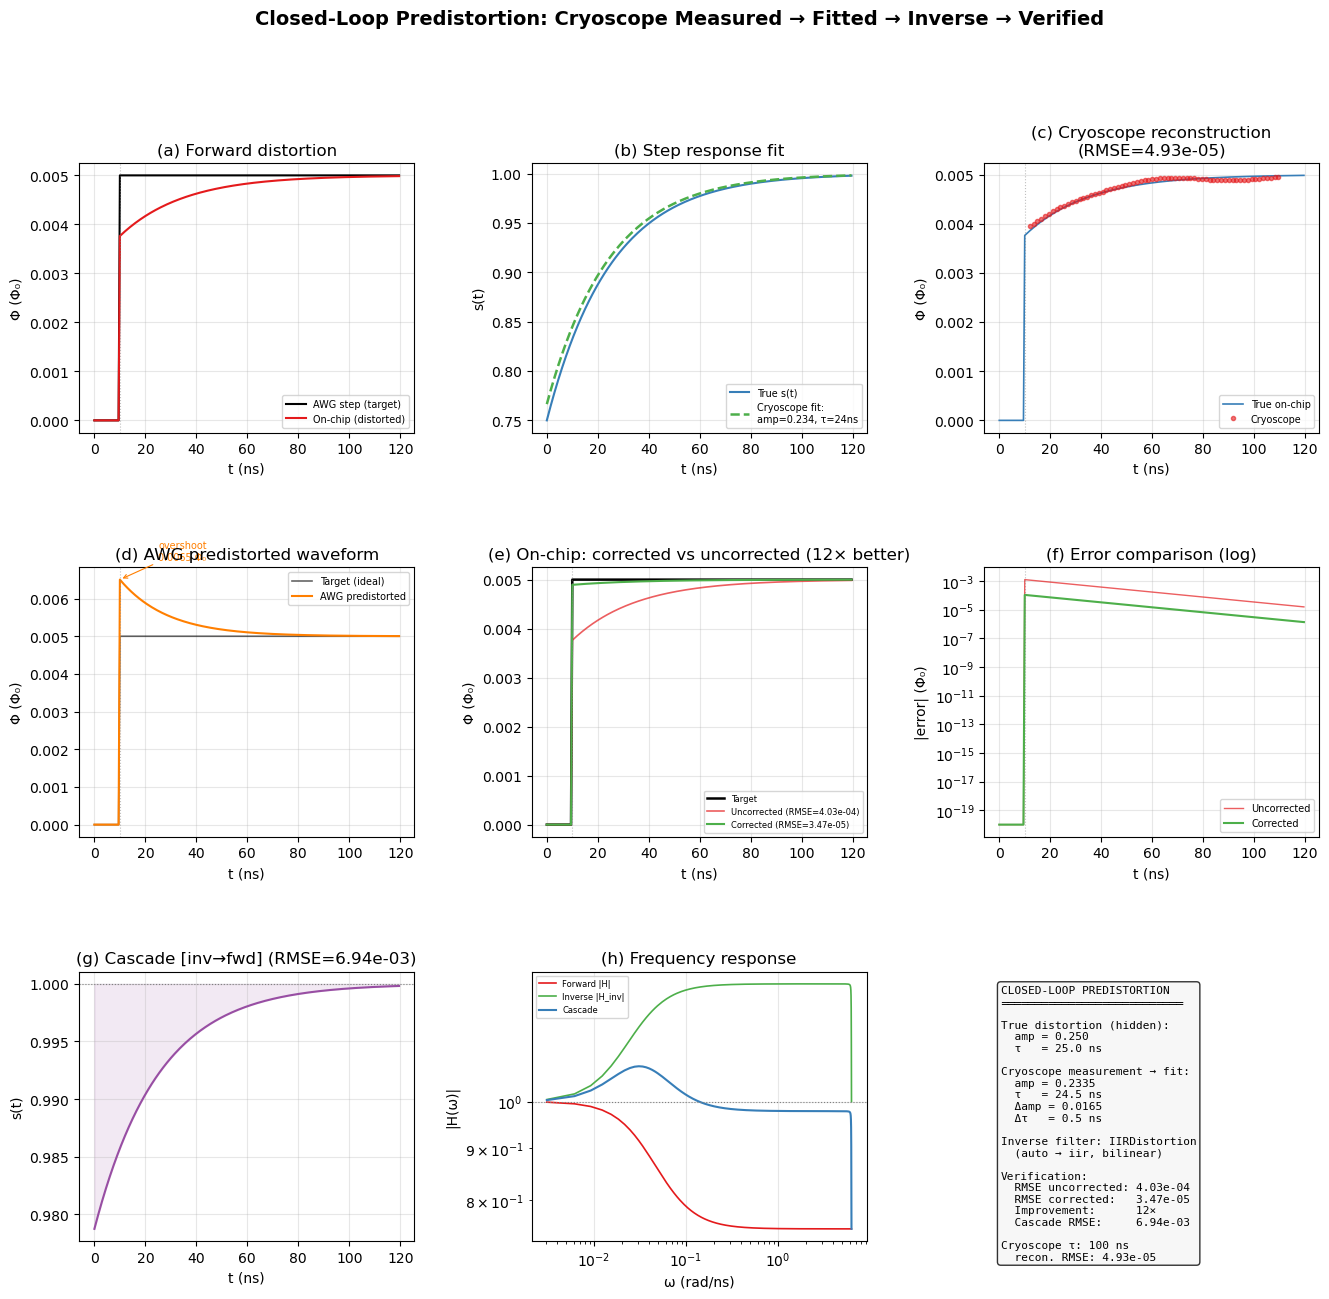


Closed-loop predistortion calibration complete!
  Cryoscope measured: amp=0.2335, τ=24.5 ns
  True distortion:    amp=0.250, τ=25.0 ns
  Predistortion improvement: 12× RMSE reduction
  Cascade [inv→fwd] ≈ identity: RMSE = 6.94e-03


In [32]:
# ═══════════════════════════════════════════════════════════════════════════
# 5. 基于 Cryoscope 测得的失真模型 → 设计预失真滤波器
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 64)
print("Step 3: Design predistortion filter from cryoscope-measured model")
print("=" * 64)

dt = float(CONFIG.awg.dt)

# PredistortionDesigner: auto → SingleExponential → IIR bilinear inverse
designer = PredistortionDesigner(method="auto")
inverse_model = designer.design(measured_model, dt=dt)
print(f"Inverse model: {type(inverse_model).__name__}")
if hasattr(inverse_model, 'b_coeffs'):
    print(f"  IIR b = {np.array2string(inverse_model.b_coeffs, precision=4)}")
    print(f"  IIR a = {np.array2string(inverse_model.a_coeffs, precision=4)}")

# ═══════════════════════════════════════════════════════════════════════════
# 6. 验证：预失真 → 控制线失真 → 片上校正波形
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 64)
print("Step 4: Verify — apply predistortion, then forward distortion")
print("=" * 64)

# 6a. AWG 预失真波形
awg_predistorted = inverse_model.apply_to_waveform(step_wf)

# 6b. 通过失真控制线 → 片上校正后波形
on_chip_corrected = line.apply(awg_predistorted)

# 6c. 指标
def rmse(wf_samples, target_samples):
    return float(np.sqrt(np.mean((np.asarray(wf_samples) - np.asarray(target_samples))**2)))

rmse_uncorrected = rmse(on_chip_uncorrected.samples, step_raw)
rmse_corrected   = rmse(on_chip_corrected.samples,   step_raw)
improvement      = rmse_uncorrected / max(rmse_corrected, 1e-30)

print(f"RMSE (uncorrected): {rmse_uncorrected:.2e} Φ₀")
print(f"RMSE (corrected):   {rmse_corrected:.2e} Φ₀")
print(f"Improvement factor: {improvement:.1f}×")

# 6d. 级联验证：[逆滤波器] → [真实失真] 应 ≈ identity
cascade = CascadeDistortion(stages=[inverse_model, true_dist])
cascade_step = cascade.step_response(t_theory)
cascade_rmse = float(np.sqrt(np.mean((cascade_step - 1.0)**2)))
print(f"Cascade [inv → fwd] step response RMSE vs ideal 1.0: {cascade_rmse:.2e}")

# ═══════════════════════════════════════════════════════════════════════════
# 综合 9 面板可视化
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# ── Row 0: 失真 + 阶跃响应拟合 + Cryoscope 重建 ──

ax = fig.add_subplot(gs[0, 0])
ax.plot(t_flux, step_raw, 'k-', lw=1.5, label='AWG step (target)')
ax.plot(t_flux, on_chip_uncorrected.samples, '#e41a1c', lw=1.5, label='On-chip (distorted)')
ax.axvline(x=step_t, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.set(xlabel='t (ns)', ylabel='Φ (Φ₀)', title='(a) Forward distortion')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[0, 1])
ax.plot(t_theory, s_theory, '#377eb8', lw=1.5, label='True s(t)')
s_fit_curve = 1.0 - fit_amp * np.exp(-np.maximum(t_theory, 0) / max(fit_tau, 1e-9))
ax.plot(t_theory, s_fit_curve, '--', color='#4daf4a', lw=1.8,
        label=f'Cryoscope fit:\namp={fit_amp:.3f}, τ={fit_tau:.0f}ns')
ax.set(xlabel='t (ns)', ylabel='s(t)', title='(b) Step response fit')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[0, 2])
ax.plot(t_flux, on_chip_uncorrected.samples, '#377eb8', lw=1.2, label='True on-chip')
ax.plot(t_rec, h_rec, 'o', color='#e41a1c', ms=3, alpha=0.6, label='Cryoscope')
ax.axvline(x=step_t, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.set(xlabel='t (ns)', ylabel='Φ (Φ₀)',
       title=f'(c) Cryoscope reconstruction\n(RMSE={rmse_cryo:.2e})')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── Row 1: 预失真 + 校正效果 + 误差 ──

ax = fig.add_subplot(gs[1, 0])
ax.plot(t_flux, step_raw, 'k-', lw=1.2, alpha=0.6, label='Target (ideal)')
ax.plot(t_flux, awg_predistorted.samples, '#ff7f00', lw=1.5, label='AWG predistorted')
ax.axvline(x=step_t, color='gray', ls=':', lw=0.8, alpha=0.5)
peak_idx = int(np.argmax(np.abs(awg_predistorted.samples)))
peak_val = awg_predistorted.samples[peak_idx]
ax.annotate(f'overshoot\n{peak_val:.4f} Φ₀',
            xy=(t_flux[peak_idx], peak_val),
            xytext=(t_flux[peak_idx]+15, peak_val*1.08),
            arrowprops=dict(arrowstyle='->', color='#ff7f00', lw=0.8),
            fontsize=7, color='#ff7f00')
ax.set(xlabel='t (ns)', ylabel='Φ (Φ₀)', title='(d) AWG predistorted waveform')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[1, 1])
ax.plot(t_flux, step_raw, 'k-', lw=1.8, label='Target')
ax.plot(t_flux, on_chip_uncorrected.samples, '#e41a1c', lw=1.2, alpha=0.7,
        label=f'Uncorrected (RMSE={rmse_uncorrected:.2e})')
ax.plot(t_flux, on_chip_corrected.samples, '#4daf4a', lw=1.5,
        label=f'Corrected (RMSE={rmse_corrected:.2e})')
ax.axvline(x=step_t, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.set(xlabel='t (ns)', ylabel='Φ (Φ₀)',
       title=f'(e) On-chip: corrected vs uncorrected ({improvement:.0f}× better)')
ax.legend(fontsize=6); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[1, 2])
err_u = np.abs(on_chip_uncorrected.samples - step_raw) + 1e-20
err_c = np.abs(on_chip_corrected.samples - step_raw) + 1e-20
ax.semilogy(t_flux, err_u, '#e41a1c', lw=1, alpha=0.7, label='Uncorrected')
ax.semilogy(t_flux, err_c, '#4daf4a', lw=1.5, label='Corrected')
ax.axvline(x=step_t, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.set(xlabel='t (ns)', ylabel='|error| (Φ₀)', title='(f) Error comparison (log)')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── Row 2: 级联 + 频响 + 总结 ──

ax = fig.add_subplot(gs[2, 0])
ax.plot(t_theory, cascade_step, '#984ea3', lw=1.5)
ax.axhline(y=1.0, color='gray', ls=':', lw=0.8)
ax.fill_between(t_theory, 1.0, cascade_step, alpha=0.12, color='#984ea3')
ax.set(xlabel='t (ns)', ylabel='s(t)',
       title=f'(g) Cascade [inv→fwd] (RMSE={cascade_rmse:.2e})')
ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[2, 1])
freqs = np.fft.rfftfreq(4096, d=dt) * 2 * np.pi
H_fwd = true_dist.frequency_response(freqs)
H_inv = inverse_model.frequency_response(freqs)
H_cas = cascade.frequency_response(freqs)
m = freqs > 1e-4
ax.loglog(freqs[m], np.abs(H_fwd[m]), '#e41a1c', lw=1.2, label='Forward |H|')
ax.loglog(freqs[m], np.abs(H_inv[m]), '#4daf4a', lw=1.2, label='Inverse |H_inv|')
ax.loglog(freqs[m], np.abs(H_cas[m]), '#377eb8', lw=1.5, label='Cascade')
ax.axhline(y=1.0, color='gray', ls=':', lw=0.8)
ax.set(xlabel='ω (rad/ns)', ylabel='|H(ω)|', title='(h) Frequency response')
ax.legend(fontsize=6); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[2, 2])
ax.axis('off')
summary = (
    "CLOSED-LOOP PREDISTORTION\n"
    "═══════════════════════════\n\n"
    f"True distortion (hidden):\n"
    f"  amp = {true_dist.amplitude:.3f}\n"
    f"  τ   = {true_dist.tau:.1f} ns\n\n"
    f"Cryoscope measurement → fit:\n"
    f"  amp = {fit_amp:.4f}\n"
    f"  τ   = {fit_tau:.1f} ns\n"
    f"  Δamp = {abs(fit_amp-true_dist.amplitude):.4f}\n"
    f"  Δτ   = {abs(fit_tau-true_dist.tau):.1f} ns\n\n"
    f"Inverse filter: {type(inverse_model).__name__}\n"
    f"  (auto → iir, bilinear)\n\n"
    f"Verification:\n"
    f"  RMSE uncorrected: {rmse_uncorrected:.2e}\n"
    f"  RMSE corrected:   {rmse_corrected:.2e}\n"
    f"  Improvement:      {improvement:.0f}×\n"
    f"  Cascade RMSE:     {cascade_rmse:.2e}\n\n"
    f"Cryoscope τ: {CRYO_TAU:.0f} ns\n"
    f"  recon. RMSE: {rmse_cryo:.2e}"
)
ax.text(0.05, 0.95, summary, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.8))

fig.suptitle('Closed-Loop Predistortion: Cryoscope Measured → Fitted → Inverse → Verified',
             fontsize=14, y=0.99, fontweight='bold')
plt.show()

print("\n" + "=" * 64)
print("Closed-loop predistortion calibration complete!")
print(f"  Cryoscope measured: amp={fit_amp:.4f}, τ={fit_tau:.1f} ns")
print(f"  True distortion:    amp={true_dist.amplitude:.3f}, τ={true_dist.tau:.1f} ns")
print(f"  Predistortion improvement: {improvement:.0f}× RMSE reduction")
print(f"  Cascade [inv→fwd] ≈ identity: RMSE = {cascade_rmse:.2e}")
print("=" * 64)